In [21]:
pip install ucimlrepo

In [22]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

# ML models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [23]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
statlog_german_credit_data = fetch_ucirepo(id=144)

# data (as pandas dataframes)
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets

# metadata
print(statlog_german_credit_data.metadata)

# variable information
print(statlog_german_credit_data.variables)


{'uci_id': 144, 'name': 'Statlog (German Credit Data)', 'repository_url': 'https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data', 'data_url': 'https://archive.ics.uci.edu/static/public/144/data.csv', 'abstract': 'This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1000, 'num_features': 20, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other', 'Marital Status', 'Age', 'Occupation'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5NC77', 'creators': ['Hans Hofmann'], 'intro_paper': None, 'additional_info': {'summary': 'Two datasets are provided.  the original dataset, in the form provided by

In [24]:
# 1. Load Dataset
data = fetch_ucirepo(id=144)

X = data.data.features
y = data.data.targets


In [25]:
# 2. Handle Categorical Features
X = X.copy()

label_encoders = {}

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le


In [26]:
# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [27]:
# 4. Feature Scaling (for LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# 5. Models
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train.values.ravel())

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train.values.ravel())

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train.values.ravel())

RandomForestClassifier(random_state=42)

In [29]:
# 6. Evaluation Function
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

In [30]:
# 7. Evaluate Models

# Logistic Regression uses scaled data
evaluate_model(lr, X_test_scaled, y_test, "Logistic Regression")

# Tree models use original data
evaluate_model(dt, X_test, y_test, "Decision Tree")

evaluate_model(rf, X_test, y_test, "Random Forest")


===== Logistic Regression =====
Confusion Matrix:
 [[127  14]
 [ 30  29]]

Classification Report:
               precision    recall  f1-score   support

           1       0.81      0.90      0.85       141
           2       0.67      0.49      0.57        59

    accuracy                           0.78       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.77      0.78      0.77       200

ROC-AUC Score: 0.8170453179468686

===== Decision Tree =====
Confusion Matrix:
 [[124  17]
 [ 30  29]]

Classification Report:
               precision    recall  f1-score   support

           1       0.81      0.88      0.84       141
           2       0.63      0.49      0.55        59

    accuracy                           0.77       200
   macro avg       0.72      0.69      0.70       200
weighted avg       0.75      0.77      0.76       200

ROC-AUC Score: 0.7822454621949754

===== Random Forest =====
Confusion Matrix:
 [[131  10]
 [ 29  30]]

Classification

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

In [33]:
from sklearn.metrics import precision_recall_curve

def plot_precision_recall(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()

In [34]:
def plot_feature_importance(model, X):
    importances = model.feature_importances_
    feature_names = X.columns

    # Sort features
    indices = importances.argsort()[::-1]

    plt.figure()
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
    plt.title("Feature Importance")
    plt.show()

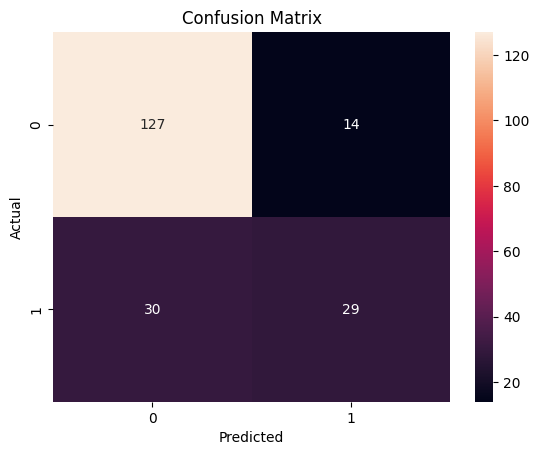

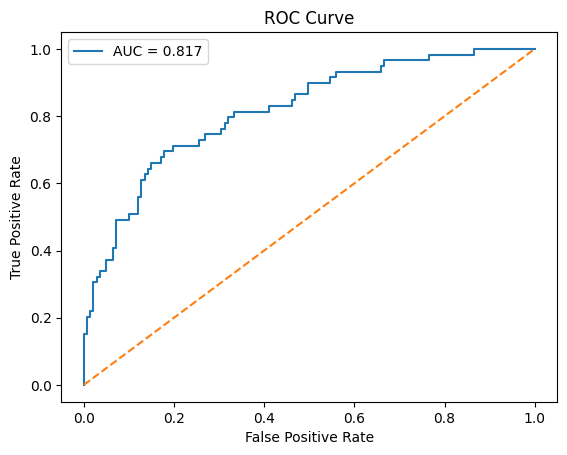

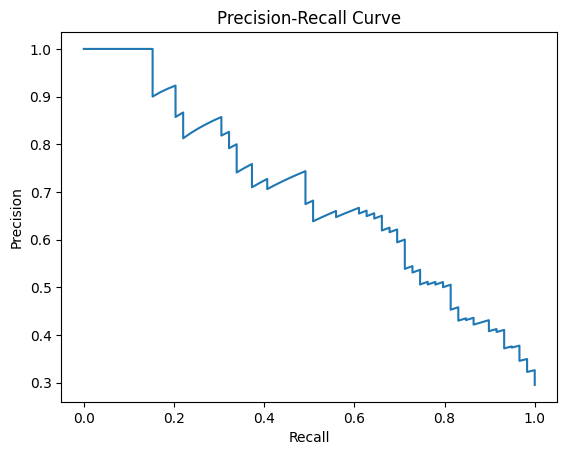

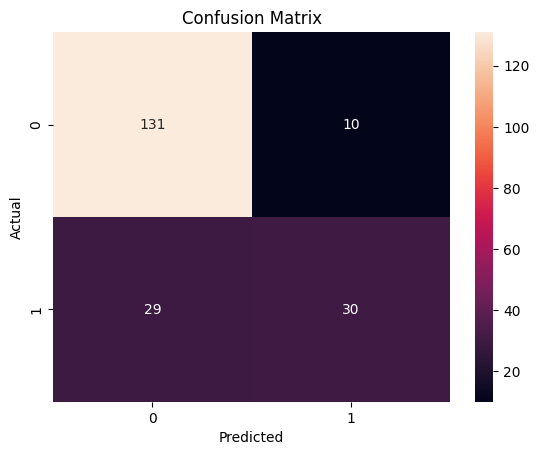

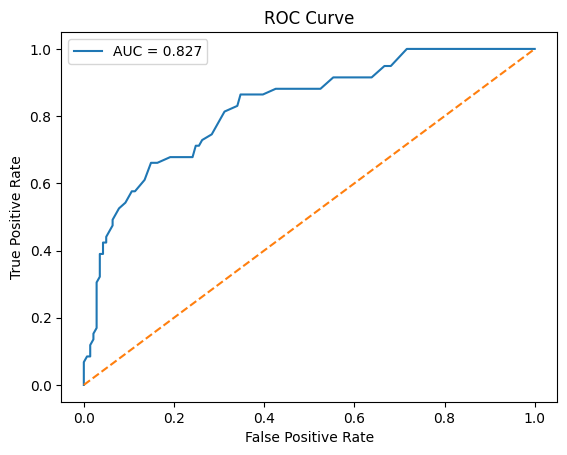

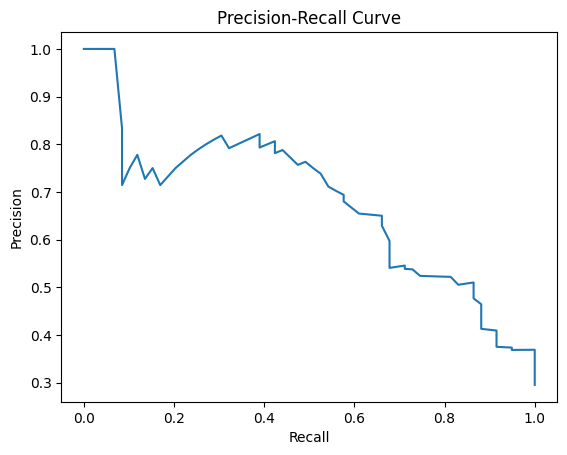

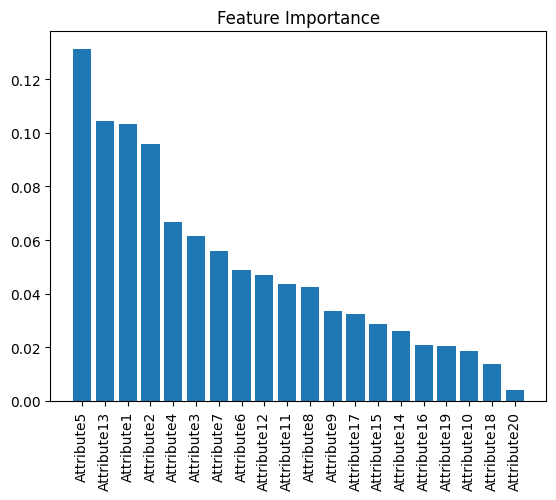

In [35]:
# Create a modified y_test with 0 and 1 labels for plotting functions
# Assuming '1' (good credit) maps to 0 and '2' (bad credit) maps to 1
y_test_binary = y_test['class'].apply(lambda x: 0 if x == 1 else 1)

# Logistic Regression (scaled)
plot_confusion_matrix(lr, X_test_scaled, y_test)
plot_roc(lr, X_test_scaled, y_test_binary)
plot_precision_recall(lr, X_test_scaled, y_test_binary)

# Random Forest (best for feature importance)
plot_confusion_matrix(rf, X_test, y_test)
plot_roc(rf, X_test, y_test_binary)
plot_precision_recall(rf, X_test, y_test_binary)

# Feature importance
plot_feature_importance(rf, X)